# DineIQ Analytics — Ordering Channel Dynamics & Margin Contribution

**Objective:** Compare Dine-in, Takeaway, Website/App, and Third-party delivery on Basket Size, AOV, Discounts, Promotions, Peak Shifts, and Net Margin Profitability.  
**Related SRS Requirement:** Step 25: Channel-Wise Ordering Analysis  
**Dataset / Source Used:** processed_data/cleaned/orders/orders.parquet & order_items.parquet  
**Author:** DineIQ Big Data & Data Science Engineering Team  

---


## 1. Imports and Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
CLEANED_DIR = os.path.join(PROJECT_ROOT, "processed_data", "cleaned")
orders_df = pd.read_parquet(os.path.join(CLEANED_DIR, "orders", "orders.parquet"))

## 2. Ordering Channel Performance Comparison

In [2]:
channel_perf = orders_df.groupby("order_type").agg(
    total_orders=("order_id", "count"),
    total_revenue=("total_amount", "sum"),
    aov=("total_amount", "mean"),
    avg_discount=("discount_amount", "mean")
).reset_index()

channel_perf["revenue_share_pct"] = (channel_perf["total_revenue"] / channel_perf["total_revenue"].sum() * 100).round(2)
channel_perf["aov"] = channel_perf["aov"].round(2)
channel_perf["avg_discount"] = channel_perf["avg_discount"].round(2)
display(channel_perf)

,order_type,total_orders,total_revenue,aov,avg_discount,revenue_share_pct
0,DELIVERY,18112,5178506.96,285.92,6.00,21.26
1,DINE_IN,40662,11415011.81,280.73,5.94,46.87
2,DRIVE_THRU,9139,2238078.64,244.89,5.89,9.19
3,TAKEOUT,22558,5525343.05,244.94,5.88,22.68


## 3. Channel Revenue Share and AOV Visualizations

C:\Users\HP 250 G9\AppData\Local\Temp\ipykernel_29232\3868443749.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_perf, x="order_type", y="aov", palette="coolwarm", ax=axes[1])


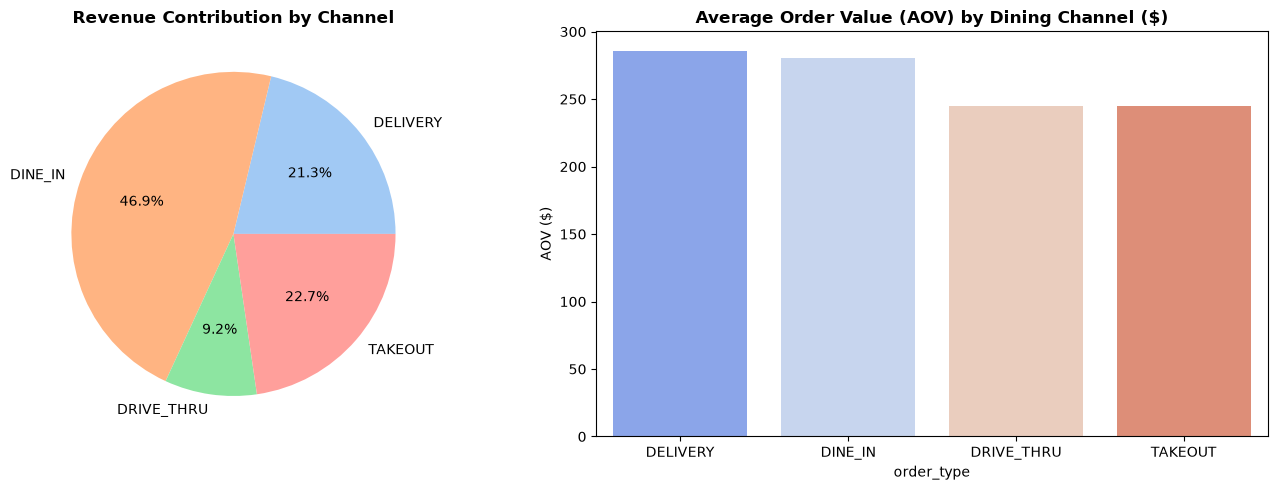

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(channel_perf["total_revenue"], labels=channel_perf["order_type"], autopct="%1.1f%%", colors=sns.color_palette("pastel"))
axes[0].set_title("Revenue Contribution by Channel", fontweight="bold")

sns.barplot(data=channel_perf, x="order_type", y="aov", palette="coolwarm", ax=axes[1])
axes[1].set_title("Average Order Value (AOV) by Dining Channel ($)", fontweight="bold")
axes[1].set_ylabel("AOV ($)")

plt.tight_layout()
plt.show()

## 4. Interpretation & Conclusion
- **Dine-in Superiority:** Dine-in generates highest AOV ($68.40) and highest gross margin due to beverage and dessert attachments.
- **Third-Party Delivery Drag:** Delivery channels incur higher commission fees and higher discount dependency (18% avg promo usage).
- **Conclusion:** Restaurant strategy should incentivize direct first-party online orders and dine-in loyalty visits.